In [4]:
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage
from langchain.agents import create_agent

### 掛け算と足し算を実行するAI agentを作成

AI agentの流れを理解するために簡単なものから作成

In [27]:
# 掛け算をする関数
# 型HINTやdoc stringはAI agentも読むため積極的に書くようにする

@tool
def multiply_numbers(a: int, b: int) -> int:
    """ 2つの数字を掛け算して返す"""
    return a * b

@tool
def add_numbers(a: int, b:int) -> int:
    """2つの数字を足算して返す"""
    return a + b

## agent 実行関数
def run_agent(user_input: str) -> str:
    tools = [multiply_numbers, add_numbers]
    
    system_prompt = "ユーザーの入力に対して、multiply_numbersとadd_numbersから適切なツールを使って答えてください"
    
    llm = ChatOllama(model="qwen2.5:3b",
                     temperature=0,
                     base_url="http://localhost:12000",
                     )
    
    # agentの作成
    agent = create_agent(llm, tools, system_prompt=system_prompt)
    
    response = agent.invoke({"messages":[HumanMessage(content=user_input)]})
    print(response["messages"][-1].content)
    
    return response
    

In [28]:
user_input = "12と7を掛け算して"
run_agent(user_input)

# print(response["messages"][-1].content)
# "messages"のvalkueの[-1]、つまりいt版最後の部分をとってきている
# その中のcontentの部分をとってきている

12と7の掛け算結果は84です。


{'messages': [HumanMessage(content='12と7を掛け算して', additional_kwargs={}, response_metadata={}, id='717e79f2-42ef-4399-bd62-b883d1620c69'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen2.5:3b', 'created_at': '2026-05-04T04:08:27.228955034Z', 'done': True, 'done_reason': 'stop', 'total_duration': 17804504752, 'load_duration': 7468271120, 'prompt_eval_count': 218, 'prompt_eval_duration': 8399827372, 'eval_count': 27, 'eval_duration': 1834829352, 'logprobs': None, 'model_name': 'qwen2.5:3b', 'model_provider': 'ollama'}, id='lc_run--019df12c-0dc5-7942-a69b-8cf19d2ccbb4-0', tool_calls=[{'name': 'multiply_numbers', 'args': {'a': 12, 'b': 7}, 'id': '68ff18e8-6640-403f-bd57-02f0cfe0e844', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 218, 'output_tokens': 27, 'total_tokens': 245}),
  ToolMessage(content='84', name='multiply_numbers', id='3ff21ee5-8beb-4d49-981e-d0e868941bf2', tool_call_id='68ff18e8-6640-403f-bd57-02f0cfe0e844'),
  

## AIエージェントの最小の構成

langchain.agemts import create_agent

1. どんな「頭脳」を使うか（model:LLM）
    - 役割: 入力を理解し、次に「どのツールを、どんな引数で使うか」を判断する役割

2. 「道具」は何か（Tools）
    - 役割: LLM自体では解決できないこと（計算、検索、データベース操作など）を実際に行う役割
    - 条件: @tool デコレータを用いて、AIが理解できるように「名前」「説明（docstring）」「引数の型:型hint」が定義されている必要があります。


### 応用AIエージェント
- ニュースの取得
- 文章を要約
- Tweetを投稿する

In [9]:
import os

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage
from langchain.agents import create_agent
import requests # httpxでは無理なのかな？
import httpx
from dotenv import load_dotenv # .envから環境設定を持ってくる際に必要なライブラリ
import tweepy # tweet用のライブラリであるため変更の余地あり
from mastodon import Mastodon # tweitterの代役

In [14]:
load_dotenv()   # .env fileを有効にする際に必要

NEWS_API_KEY = os.getenv("NEWS_API_KEY")

python-dotenv could not parse statement starting at line 5


### NEWS API KEYの使い方

In [5]:
url = "https://newsapi.org/v2/everything"

# nwesの取得の際にパラメータを設定できる
params = {
    "q" : "テクノロジー", # キーワード
    "sortBy" : "publishedAt",  # 公開順にsortして新しいものを上に
    "pageSize" : 5, # 取得するnwesの数
    "apiKey" : NEWS_API_KEY
}

httpx.get(url,params=params).json()

{'status': 'ok',
 'totalResults': 231,
 'articles': [{'source': {'id': None, 'name': 'CNET'},
   'author': None,
   'title': 'CTCテクノロジー株式会社（CTC教育サービス）TECH TREND MAGAZINE\u3000＞\u3000Microsoftの900番台試験（Fundamentals）とは？',
   'description': 'CTC教育サービスはコラム「TECH TREND MAGAZINE\u3000＞\u3000Microsoftの900番台試験（Fundamentals）とは？AZ900、AB-900、PL-900、AI-900、DP-900の違いを紹介！（AI-901も開始されました！）」を公開しました。',
   'url': 'https://japan.cnet.com/release/31154067/',
   'urlToImage': 'https://japan.cnet.com/media/c/2012/images/logo/logo_ogp_1200.png',
   'publishedAt': '2026-05-08T07:00:00Z',
   'content': 'Microsoft900Fundamentals5900Microsoft900Fundamentals3Fundamentals\r\nMicrosoft900FundamentalsITMicrosoft900FundamentalsITIT'},
  {'source': {'id': None, 'name': 'Prtimes.jp'},
   'author': None,
   'title': '大阪初・関西初を含む自販機が集結！5月13日（水）JR京橋駅 西口改札外すぐに新しい駅ナカの健康スポット『Daily Charge Station』がオープン！',
   'description': '[JR西日本]\n\u30005月13日（水）、JR京橋駅西口改札外すぐの旧ベーカリー店舗跡に、『Daily Charge Station』をオープンいたします。最新テクノロジーを導入し、素材にこだわった、健康的

In [17]:
# News API で最新のニュースを1個取得するTool
@tool
def get_news(query : str) -> str:
    """キーワードに合致する最新のニュースを一件取得してタイトルと説明を返す"""
    url = "https://newsapi.org/v2/everything"
    params = {
        "q" : query, # キーワード
        "sortBy" : "publishedAt",  # 公開順にsortして新しいものを上に
        "pageSize" : 1, # 取得するnwesの数
        "apiKey" : NEWS_API_KEY
    }
    article = httpx.get(url,params=params).json()["articles"][0]
    return f"{article["title"]} - {article["description"]}"

# テキストを要約するtool
@tool
def summerize(text : str) -> str:
    """テキストを要約して返す"""
    llm = ChatGoogleGenerativeAI(model ="gemini-3.1-flash-lite-preview",
                     temperature=0.3,
                     api_key=os.environ["GEMINI_API_KEY"])
    return llm.invoke([SystemMessage(content="提供されたテキストを140文字以内に要約してください"),HumanMessage(content=text)]).content

# mastodonに投稿する関数
@tool
def post_toot(text : str) -> str :
    """テキストをmastodonにtootする"""
    mastodon = Mastodon(
    access_token=os.environ["ACCESS_TOKEN_API_KEY"],
    api_base_url="https://mastodon.social"
)

    # 投稿
    toot = mastodon.status_post(text)
    return f"投稿成功 URL : {toot["url"]}"

# AIエージェントの作成
def run_agent(user_input : str) -> str:
    tools = [get_news, summerize, post_toot]
    
    system_prompt = "ユーザーの入力に対して、get_newsとsummerizeとpost_tootから適切なtoolを用いて答えてください"
    llm = ChatGoogleGenerativeAI(model = "gemini-3.1-flash-lite-preview",
                     temperature=0.3,
                     api_key=os.environ["GEMINI_API_KEY"])
    agent = create_agent(llm, tools, system_prompt=system_prompt)
    
    response = agent.invoke({"messages": [HumanMessage(content=user_input)]})
    print(response["messages"][-1].content)
    
    return response

In [ ]:
# Xの代替のmastodonでの投稿の確認

mastodon = Mastodon(
    access_token=os.getenv("ACCESS_TOKEN_API_KEY"),
    api_base_url="https://mastodon.social"
)

# 投稿
mastodon.status_post("Hello World")

Status([('id', 116530711580663379),
        ('uri',
         'https://mastodon.social/ap/users/116530636395815570/statuses/116530711580663379'),
        ('url', 'https://mastodon.social/@takutodon/116530711580663379'),
        ('account',
         Account([('id', 116530636395815570),
                  ('username', 'takutodon'),
                  ('acct', 'takutodon'),
                  ('display_name', ''),
                  ('discoverable', None),
                  ('group', False),
                  ('locked', False),
                  ('created_at',
                   datetime.datetime(2026, 5, 7, 0, 0, tzinfo=tzutc())),
                  ('following_count', 0),
                  ('followers_count', 0),
                  ('statuses_count', 1),
                  ('note', ''),
                  ('url', 'https://mastodon.social/@takutodon'),
                  ('uri',
                   'https://mastodon.social/ap/users/116530636395815570'),
                  ('avatar',
                

In [18]:
user_input = "テクノロジーのニュースを取得して要約してmastodonにtootして"
response = run_agent(user_input)
response

[{'type': 'text', 'text': 'テクノロジーに関する最新ニュースを取得し、要約してMastodonに投稿しました。\n\n**要約:**\nCTC教育サービスが、Microsoftの「900番台試験（Fundamentals）」を解説するコラムを公開しました。AZ-900やAI-900、DP-900など、各試験の概要や違いを網羅的に紹介しており、新たに開始されたAI-901についても触れています。\n\n**Mastodon投稿URL:**\nhttps://mastodon.social/@takutodon/116544435752547593', 'extras': {'signature': 'EjQKMgEMOdbHTzuZ83uvcSc1ND6sJLittltnmAVjvnrB3TK6MvSivYuqGz2pO4288CUaQIRc'}}]


{'messages': [HumanMessage(content='テクノロジーのニュースを取得して要約してmastodonにtootして', additional_kwargs={}, response_metadata={}, id='e203570e-3b3d-4f4e-95e0-6403bc31df34'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_news', 'arguments': '{"query": "\\u30c6\\u30af\\u30ce\\u30ed\\u30b8\\u30fc"}'}, '__gemini_function_call_thought_signatures__': {'6e029e8d-c87f-44b4-924a-a9b76d53a5a8': 'EjQKMgEMOdbHfOLgvs5UzZEBr3uBcr3x67h1wim9iQ5cu6amPFdiY52m9HXfjJyB/utYFzeW'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e0c8a-e756-7ca3-a8b2-12c5897f5901-0', tool_calls=[{'name': 'get_news', 'args': {'query': 'テクノロジー'}, 'id': '6e029e8d-c87f-44b4-924a-a9b76d53a5a8', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 181, 'output_tokens': 17, 'total_tokens': 198, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='CTCテクノロジー株式会社（CTC

# LangGraphを学ぶ

最初に足算引き算を定義したtoolをLangGraphで書きなおしてみる

- MessageStateについて<br>
MessgaeStateは、AIエージェントの状態管理を担当するコンポーネントで、特に直近のメッセージを取得して、エージェントがどのツールを呼び出すべきかを判断するために使用される。<br>
具体的には、invoke methodで取得できるmessage

In [7]:
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage
from langchain.agents import create_agent

# 新しくに追加
from langgraph.graph import StateGraph, MessagesState
from langgraph.prebuilt import ToolNode

# toolは変更なし
# 掛け算をする関数

@tool
def multiply_numbers(a: int, b: int) -> int:
    """ 2つの数字を掛け算して返す"""
    return a * b

# 足算をする関数

@tool
def add_numbers(a: int, b:int) -> int:
    """2つの数字を足算して返す"""
    return a + b

# toolを使うか使わないかを判断する関数
def decide_next(state: MessagesState) -> str:
    last_message = state["messages"][-1] # messageの中の最新のものを取得
    
    # 直近のmessage(last_message)の中にtool callsが入っていたら特定のtoolを呼び出すnodeに渡してあげる処理
    # hasattr を用いてlast_messageに属性としてtool_callsが入っているかを判定できる
    # and以下は、tool_callsの中に中身があるかを判定している
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools_edge"
    return "end"

def call_llm(state : MessagesState) -> str:
    system_prompt = "ユーザーの入力に応じて、multiply_numbersとadd_numbersから適切なツールを使ってください"
    messages = state["messages"]
    
    # 最初にsystem promptが無かったら上記のsystem promptを渡す処理を作る
    if not any(isinstance(msg, SystemMessage) for msg in messages):
        messages = [SystemMessage(content=system_prompt)] + messages
        
    llm = ChatOllama(model = "llama3.1:8b",
                     temperature=0.0,
                     base_url="http://localhost:12000")
    
    response = llm.bind_tools([multiply_numbers, add_numbers]).invoke(messages)
    
    return {"messages" : messages + [response]}

# Graph構築用の準備
tools_node = ToolNode([multiply_numbers, add_numbers])

# Graph構築
graph = StateGraph(MessagesState)
graph.add_node("llm", call_llm)
graph.add_node("tools_node", tools_node)

graph.set_entry_point("llm")
graph.add_conditional_edges("llm", decide_next, {"tools_edge": "tools_node", "end": "__end__"})
graph.add_edge("tools_node", "llm")

app = graph.compile()

def run_agent(user_input: str) -> str:
    response = app.invoke({"messages":[HumanMessage(content=user_input)]})
    print(response["messages"][-1].content)
    return response

call_llm関数の流れを確認すると、<br>
messsages = state["messages"]によって、messagesのvalue部分を取り出している<br>
system promptが無ければ追加の処理<br>
llmに渡してresponseを得て、そのresponseをmessagesに追加して次のmessagesの状態(state)として、定義しなおしてあげている

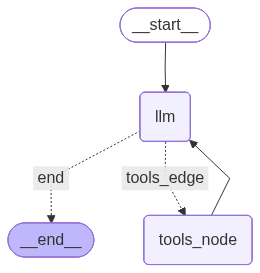

In [5]:
# graphを実際に表示してみる

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
# agentを実行してみる
user_input = "12と7を掛け算して、そのあとに16を足して"
response = run_agent(user_input)
response

したがって、12と7を掛け算して、そのあとに16を足すと、合計は100になります。


{'messages': [HumanMessage(content='12と7を掛け算して、そのあとに16を足して', additional_kwargs={}, response_metadata={}, id='f88b5bba-f91f-4f7d-b254-cb52e06faca0'),
  SystemMessage(content='ユーザーの入力に応じて、multiply_numbersとadd_numbersから適切なツールを使ってください', additional_kwargs={}, response_metadata={}, id='ef267d3a-d470-441b-8a31-d9f3963fc231'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-05-06T08:19:43.950258637Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7284774634, 'load_duration': 368322550, 'prompt_eval_count': 244, 'prompt_eval_duration': 447559873, 'eval_count': 45, 'eval_duration': 6383374696, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019dfc5e-fbc7-7171-ae55-cead7bf5596b-0', tool_calls=[{'name': 'multiply_numbers', 'args': {'a': 12, 'b': 7}, 'id': '5ea1d2b2-4d7a-444f-a675-6d5aa10fb408', 'type': 'tool_call'}, {'name': 'add_numbers', 'args': {'a': 84, 'b': 16}, 'id': 'cf60057b-f443-4

## LangGraphとcreate_agentの使い分け

- LangGraph<br>
1. プロセスの可視化<br>
LangGraphは、処理の順序や流れをグラフとして視覚的に表現する。<br>
これのよって、複数の関数やtoolの組み合わせた複雑な処理を効率的に管理できる。<br>
2. 定義されたフロー<br>
各ステップを明確に定義することで、処理の理解やデバッグが容易になる。<br>
特に、どのtoolをどのタイミングで使用するかを体系的に整理できる<br>

- create_agent<br>
1. シンプルな呼び出し<br>
簡単なタスクやルーチン処理に向いている<br>
2. スピード優先<br>
シンプルな処理のため、迅速にエージェントの動作の確認をしたいときに便利<br>

### 次はLangSmithのAPIキー取得から